# Практика 2 — 4 модели и GridSearchCV

**Модуль 03 · AI HUB**

---

## Что делаем в этой практике

Прежде чем переходить к CatBoost и Optuna — прогоняем несколько классических моделей через единый Pipeline и GridSearchCV. Это важный шаг: нужно убедиться, что CatBoost действительно лучше, а не просто «запустили другую библиотеку».

1. Собираем общую функцию `run(model, params)` с GridSearchCV внутри
2. Прогоняем: LogReg, LinearSVC, DecisionTree, LightGBM
3. Сводим результаты в DataFrame — честное сравнение на одном TF-IDF, одном CV, одном `scoring='f1'`
4. Выбираем лучшую модель и объясняем выбор


## Настройка окружения

Установите LightGBM, если ещё нет:
```bash
pip install lightgbm
```

#подлючи гугл диск если надо

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print("Всё импортировано успешно.")

Всё импортировано успешно.


---

## Задание 1 — Загрузка данных и CV

**Что нужно сделать:**
1. Загрузите `SMSSpamCollection`, создайте `is_spam`, удалите пустые строки
2. Добавьте мета-признаки (`len`, `caps_ratio`, `exclaim_ratio`, `digit_ratio`) — как в Практике 1
3. Создайте единый `cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`
4. Сохраните `X_text = df['text']` и `y = df['is_spam']`
5. Выведите `X_text.shape`

In [36]:
# Загрузите SMSSpamCollection, создайте is_spam, удалите пустые строки
df=pd.read_csv ('data.csv', encoding='cp1251')
df['is_spam'] = (df['v1'] == 'spam').astype(int)
df = df.drop(['v1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1)
df = df.rename(columns={'v2': 'text'})
df = df.dropna(subset=['text'])
df = df[df['text'].str.strip() != '']

# Добавьте мета-признаки (len, caps_ratio, exclaim_ratio, digit_ratio) — как в Практике 1
# df['len'] = df['text'].str.len()
# df['caps_ratio'] = df['text'].apply(lambda s: sum(1 for ch in s if ch.isupper()) / max(1, len(s)))
# df['exclaim_ratio'] = df['text'].apply(lambda s: s.count('!') / max(1, len(s)))
# df['digit_ratio'] = df['text'].apply(lambda s: sum(1 for ch in s if ch.isdigit()) / max(1, len(s)))
df['len'] = df['text'].str.len()
df['caps_ratio'] = df['text'].str.count(r'[A-Z]') / df['len'].clip(lower=1)
df['exclaim_ratio'] = df['text'].str.count(r'!') / df['len'].clip(lower=1)
df['digit_ratio'] = df['text'].str.count(r'\d') / df['len'].clip(lower=1)
# Создайте единый cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Сохраните X_text = df['text'] и y = df['is_spam']
X_text = df['text']
y = df['is_spam']

print(f"X_text shape: {X_text.shape}")  
print(f"y shape: {y.shape}")            

X_text shape: (5572,)
y shape: (5572,)


---

## Задание 2 — Функция `run(model, params)`

Напишем общую обёртку, чтобы не дублировать код для каждой модели.

**Что нужно сделать:**

Напишите функцию `run(name, model, params) -> dict`, которая:
1. Собирает Pipeline из TF-IDF и модели:
   ```python
   pipe = Pipeline([
       ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=3)),
       ('clf',   model),
   ])
   ```
2. Запускает `GridSearchCV(pipe, params, cv=cv, scoring='f1', n_jobs=-1)`
3. Обучает на `X_text` / `y`
4. Возвращает словарь: `{'model': name, 'f1_cv': best_score_, 'best_params': best_params_}`
5. Выводит строку прогресса: `LogReg    F1 = 0.952  params: {...}`


In [37]:

def run(name, model, params) -> dict:
    
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=3)),
        ('clf', model)
    ])
    
    grid = GridSearchCV(pipe, params, cv=cv, scoring='f1', n_jobs=-1)
    grid.fit(X_text, y)
    
    best_score = grid.best_score_
    best_params = grid.best_params_
    
    # Вывод строки в указанном формате
    print(f"{name:<10} F1 = {best_score:.3f}  params: {best_params}")
    
    return {
        'model': name,
        'f1_cv': best_score,
        'best_params': best_params
    }

params_lr = {
    'clf__C': [0.1, 1.0, 10.0],
    'clf__solver': ['liblinear', 'lbfgs']
}

result = run('LogReg', LogisticRegression(max_iter=1000, class_weight='balanced'), params_lr)

LogReg     F1 = 0.952  params: {'clf__C': 10.0, 'clf__solver': 'liblinear'}


---

## Задание 3 — LogisticRegression

Это наш M2-baseline, но теперь через `GridSearchCV` — подбираем силу регуляризации `C`.

**Что нужно сделать:**

Вызовите `run()` с:
- `model = LogisticRegression(max_iter=2000, class_weight='balanced')`
- `params = {'clf__C': [0.1, 1.0, 10.0]}`

Сохраните результат и выведите лучший `C`.


In [38]:
result = run(
    name='LogReg',
    model=LogisticRegression(max_iter=2000, class_weight='balanced'),
    params={'clf__C': [0.1, 1.0, 10.0]}
)

print(result)

LogReg     F1 = 0.951  params: {'clf__C': 10.0}
{'model': 'LogReg', 'f1_cv': np.float64(0.9505551811568642), 'best_params': {'clf__C': 10.0}}


---

## Задание 4 — LinearSVC

LinearSVC часто работает так же хорошо, как LogReg на текстовых задачах, но быстрее при большом словаре.

**Что нужно сделать:**

Вызовите `run()` с:
- `model = LinearSVC(class_weight='balanced', max_iter=2000)`
- `params = {'clf__C': [0.1, 1.0]}`

Сохраните результат.


In [39]:

result_svc = run(
    name='LinearSVC',
    model=LinearSVC(class_weight='balanced', max_iter=2000),
    params={'clf__C': [0.1, 1.0]}
)

print(result_svc)

LinearSVC  F1 = 0.955  params: {'clf__C': 1.0}
{'model': 'LinearSVC', 'f1_cv': np.float64(0.9548798365839888), 'best_params': {'clf__C': 1.0}}


---

## Задание 5 — DecisionTreeClassifier

Одиночное дерево — слабая модель для текста. Запускаем как «нижнюю границу»: любая другая модель должна быть лучше.

**Что нужно сделать:**

Вызовите `run()` с:
- `model = DecisionTreeClassifier(class_weight='balanced', random_state=42)`
- `params = {'clf__max_depth': [None, 8, 16]}`

Сохраните результат.

Ожидаемый результат: F1 значительно ниже LogReg. Это нормально — дерево не умеет работать с высокоразмерным TF-IDF пространством.

In [40]:

result_dt = run(
    name='DecisionTree',
    model=DecisionTreeClassifier(class_weight='balanced', random_state=42),
    params={'clf__max_depth': [None, 8, 16]}
)

print(result_dt)

DecisionTree F1 = 0.847  params: {'clf__max_depth': 16}
{'model': 'DecisionTree', 'f1_cv': np.float64(0.8465643035951513), 'best_params': {'clf__max_depth': 16}}


---

## Задание 6 — LightGBM

Градиентный бустинг на TF-IDF признаках — интересный вариант. Хуже LogReg на чистом тексте, но позволяет добавлять мета-признаки легко.

**Что нужно сделать:**

Вызовите `run()` с:
- `model = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1)`
- `params = {'clf__num_leaves': [31, 63]}`

Сохраните результат.


In [41]:
result_lgb=run (
    name='LGBMC',
    model=LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1),
    params={'clf__num_leaves': [31, 63]}
)

print(result_lgb)

LGBMC      F1 = 0.932  params: {'clf__num_leaves': 31}
{'model': 'LGBMC', 'f1_cv': np.float64(0.9321745657553686), 'best_params': {'clf__num_leaves': 31}}


---

## Задание 7 — Сводная таблица

**Что нужно сделать:**
1. Соберите все результаты в один `pd.DataFrame` с колонками `model`, `f1_cv`, `best_params`
2. Отсортируйте по убыванию `f1_cv`
3. Выведите таблицу
4. Постройте горизонтальный barplot: ось Y — модель, ось X — `f1_cv`

          model     f1_cv              best_params
0     LinearSVC  0.954880          {'clf__C': 1.0}
1        LogReg  0.950555         {'clf__C': 10.0}
2         LGBMC  0.932175  {'clf__num_leaves': 31}
3  DecisionTree  0.846564   {'clf__max_depth': 16}


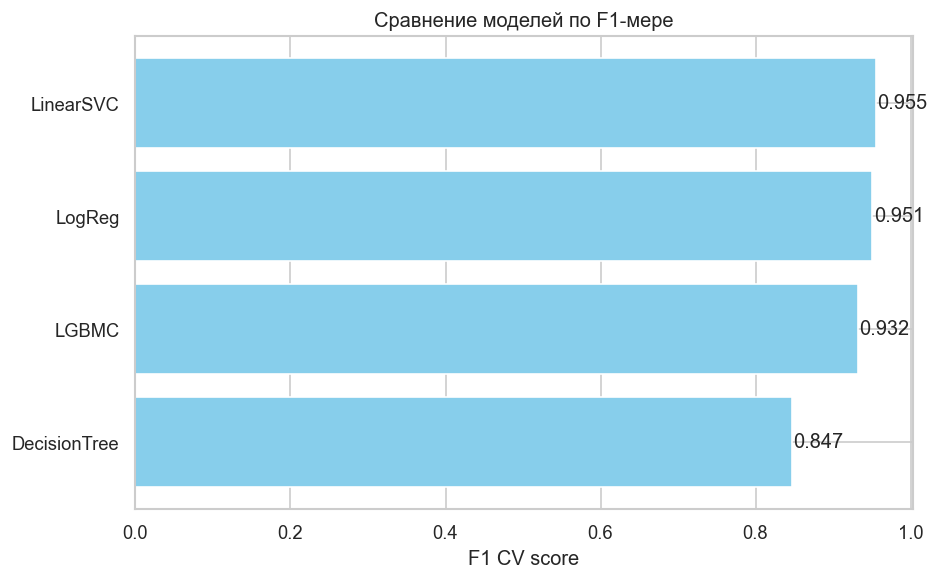

In [42]:

df_results = pd.DataFrame([result, result_svc, result_dt, result_lgb])

# Сортируем по убыванию f1_cv
df_results = df_results.sort_values('f1_cv', ascending=False).reset_index(drop=True)

# Выводим таблицу (выбираем нужные колонки)
print(df_results[['model', 'f1_cv', 'best_params']])

# Горизонтальный barplot
plt.figure(figsize=(8, 5))
plt.barh(df_results['model'], df_results['f1_cv'], color='skyblue')
plt.xlabel('F1 CV score')
plt.title('Сравнение моделей по F1-мере')
plt.gca().invert_yaxis()  # лучшая модель сверху
# Добавляем значения на планки
for i, v in enumerate(df_results['f1_cv']):
    plt.text(v + 0.002, i, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()

---

## Задание 8 — Итоговый вывод

**Заполните таблицу и ответьте на вопросы.**

| Модель | F1(spam) | Лучший параметр | Вывод |
|--------|----------|----------------|-------|
| LogReg | ? | C=? | *(напишите)* |
| LinearSVC | ? | C=? | *(напишите)* |
| DecisionTree | ? | max_depth=? | *(напишите)* |
| LightGBM | ? | num_leaves=? | *(напишите)* |

**Почему LogReg / LinearSVC лучше работают на TF-IDF, чем деревья?**  
*(напишите здесь — подсказка: подумайте о размерности признакового пространства)*
